In [1]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import * 

In [ ]:
''' 
This notebook performs volatility forecasting using past observations:
    Historical data is split into training (2014-2023) and test (2024) periods
    An N-BEATS neural network is trained
    Model results scored and recored
    Forecast is plotted against true observations

'''

In [48]:
# load prices.csv
prices = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True)
prices.tz_localize('UTC', axis='index')
print(prices.info())
prices

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2735 entries, 2014-01-01 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2735 non-null   float64
 1   CAD=X     2735 non-null   float64
dtypes: float64(2)
memory usage: 64.1 KB
None


,EURUSD=X,CAD=X
Date,,
2014-01-01,1.06193,1.374495
2014-01-02,1.06445,1.376671
2014-01-03,1.06691,1.366662
2014-01-06,1.06305,1.359601
2014-01-07,1.06609,1.363196
...,...,...
2024-06-24,1.37013,1.068776
2024-06-25,1.36579,1.073272
2024-06-26,1.36611,1.070962


In [50]:
# load returns.csv
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)
returns.tz_localize('UTC', axis='index')
print(returns.info())
returns

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2734 entries, 2014-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2734 non-null   float64
 1   CAD=X     2734 non-null   float64
dtypes: float64(2)
memory usage: 64.1 KB
None


,EURUSD=X,CAD=X
Date,,
2014-01-02,0.237312,0.158325
2014-01-03,0.231106,-0.727065
2014-01-06,-0.361792,-0.516652
2014-01-07,0.285965,0.264468
2014-01-08,1.051503,-0.114382
...,...,...
2024-06-24,0.121303,-0.174209
2024-06-25,-0.316753,0.420722
2024-06-26,0.023427,-0.215266


In [51]:
# choose which data to use for modeling
data = prices.copy()
# data = returns.copy()

In [52]:
# Split data into train, validation, and test sets
train_split = '2022-01-01'
val_split = '2023-01-01' 
train = data.loc[:'2021-12-31']
val = data.loc[train_split:'2022-12-31']
test = data.loc[val_split:]


# check

print(train.shape, val.shape, test.shape)
print(train.index.min(), train.index.max())
print(val.index.min(), val.index.max())
print(test.index.min(), test.index.max())

print("Train")
print(train)
print("Validation")
print(val)
print("Test")
print(test)


(2085, 2) (260, 2) (390, 2)
2014-01-01 00:00:00 2021-12-31 00:00:00
2022-01-03 00:00:00 2022-12-30 00:00:00
2023-01-02 00:00:00 2024-06-28 00:00:00
Train
            EURUSD=X     CAD=X
Date                          
2014-01-01   1.06193  1.374495
2014-01-02   1.06445  1.376671
2014-01-03   1.06691  1.366662
2014-01-06   1.06305  1.359601
2014-01-07   1.06609  1.363196
...              ...       ...
2021-12-27   1.28140  1.132426
2021-12-28   1.27870  1.133003
2021-12-29   1.28130  1.131478
2021-12-30   1.27826  1.136015
2021-12-31   1.27444  1.132503

[2085 rows x 2 columns]
Validation
            EURUSD=X     CAD=X
Date                          
2022-01-03   1.26588  1.137346
2022-01-04   1.27513  1.130224
2022-01-05   1.27044  1.128363
2022-01-06   1.27601  1.131350
2022-01-07   1.27302  1.129688
...              ...       ...
2022-12-26   1.35897  1.066780
2022-12-27   1.35570  1.064022
2022-12-28   1.35250  1.063717
2022-12-29   1.35994  1.062925
2022-12-30   1.35520  1.066075

[26

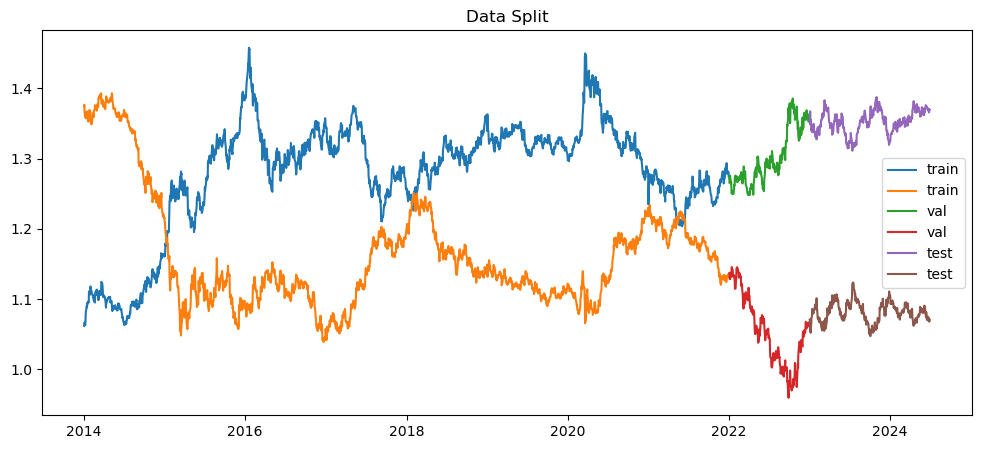

In [53]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="train")
plt.plot(val.index, val, label="val")
plt.plot(test.index, test, label="test")
plt.title("Data Split")
plt.legend()
plt.show()

In [54]:
data.reset_index(inplace=True)
train.reset_index(inplace=True)
val.reset_index(inplace=True)
test.reset_index(inplace=True)

In [55]:
data

,Date,EURUSD=X,CAD=X
0,2014-01-01,1.06193,1.374495
1,2014-01-02,1.06445,1.376671
2,2014-01-03,1.06691,1.366662
3,2014-01-06,1.06305,1.359601
4,2014-01-07,1.06609,1.363196
...,...,...,...
2730,2024-06-24,1.37013,1.068776
2731,2024-06-25,1.36579,1.073272
2732,2024-06-26,1.36611,1.070962
2733,2024-06-27,1.37045,1.068011


In [56]:
# to do: avoid 0 filling somehow

series_ts = TimeSeries.from_dataframe(
    data,
    time_col='Date',
    value_cols=list(data.columns)[1:],
    # fill_missing_dates=True,
    fillna_value=0.0,
    freq='B'
).astype(np.float32)

train_ts = TimeSeries.from_dataframe(
    train, 
    time_col='Date', 
    value_cols=list(data.columns)[1:], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )

val_ts = TimeSeries.from_dataframe(
    val, 
    time_col='Date', 
    value_cols=list(data.columns)[1:], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )
    
test_ts = TimeSeries.from_dataframe(
    test, 
    time_col='Date', 
    value_cols=list(data.columns)[1:], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )

In [57]:
train_ts

,EURUSD=X,CAD=X
Date,,
2014-01-01,1.06193,1.374495
2014-01-02,1.06445,1.376671
2014-01-03,1.06691,1.366662
2014-01-06,1.06305,1.359601
2014-01-07,1.06609,1.363196
...,...,...
2021-12-27,1.28140,1.132426
2021-12-28,1.27870,1.133003
2021-12-29,1.28130,1.131478


In [58]:
print(type(series_ts))

<class 'darts.timeseries.TimeSeries'>


In [59]:
# check null values
null_count_df = series_ts.to_dataframe()
print(null_count_df)
print(null_count_df.isna().sum())

# print where it is null if any
null_count_df[null_count_df.isna().any(axis=1)] 

            EURUSD=X     CAD=X
Date                          
2014-01-01   1.06193  1.374495
2014-01-02   1.06445  1.376671
2014-01-03   1.06691  1.366662
2014-01-06   1.06305  1.359601
2014-01-07   1.06609  1.363196
...              ...       ...
2024-06-24   1.37013  1.068776
2024-06-25   1.36579  1.073272
2024-06-26   1.36611  1.070962
2024-06-27   1.37045  1.068011
2024-06-28   1.36993  1.070847

[2738 rows x 2 columns]
EURUSD=X    0
CAD=X       0
dtype: int64


,EURUSD=X,CAD=X
Date,,


In [60]:
# Scaler
scaler = Scaler(MinMaxScaler(feature_range=(-1,1))) 

train_scaled = scaler.fit_transform(train_ts)
val_scaled = scaler.transform(val_ts)
test_scaled = scaler.transform(test_ts)
series_scaled = scaler.transform(series_ts)

In [74]:
# Define nbeats model
seed = 42
nbeats_name = "nbeats"

# parameters
params = {
    'lags': 20,
    'steps': 1,
    'stacks': 2,
    'blocks': 2,
    'layers': 2,
    'l_widths': 64,
    'epochs': 10,
    'b_size': 32
}

model_nbeats = NBEATSModel(
    input_chunk_length=params['lags'],       # use last 20 observations
    output_chunk_length=params['steps'],       # forecast 1 step ahead
    generic_architecture=True,
    num_stacks=params['stacks'],
    num_blocks=params['blocks'],
    num_layers=params['layers'],
    layer_widths=params['l_widths'],
    n_epochs=params['epochs'], 
    batch_size=params['b_size'],
    random_state=seed,
    model_name=nbeats_name,
    save_checkpoints=True,
    force_reset=True,
)

# fit model
history = model_nbeats.fit(
    train_scaled, 
    val_series=val_scaled,
    verbose=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 30.7 K | train
-------------------------------------------------------------
30.2 K    Trainable params
565       Non-trainable params
30.7 K    Total params
0.123     Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [62]:
model_nbeats = NBEATSModel.load_from_checkpoint(model_name=nbeats_name, best=True)

In [63]:
one_pred = model_nbeats.predict(n=1, series=train_scaled)
print(one_pred) 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

            EURUSD=X     CAD=X
Date                          
2022-01-03  0.748984  0.623198

shape: (1, 2, 1), freq: B, size: 16.00 B


In [64]:
print(len(train), len(val), len(test))

2085 260 390


In [65]:
print(series_scaled.start_time(), series_scaled.end_time())
print(test['Date'].iloc[0])

2014-01-01 00:00:00 2024-06-28 00:00:00
2023-01-02 00:00:00


In [66]:
# historical_forecasts rolls forward through the test period
pred_scaled = model_nbeats.historical_forecasts(
    series=series_scaled,
    start=test['Date'].iloc[0],
    forecast_horizon=1,
    stride=1,
    last_points_only=True,
    retrain=False,
    verbose=True
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [67]:
pred_ts = scaler.inverse_transform(pred_scaled) 
print(type(pred_scaled))
print(type(pred_ts))
print(type(test_ts))

print(pred_scaled)
print(pred_ts)
print(test_ts)

<class 'darts.timeseries.TimeSeries'>
<class 'darts.timeseries.TimeSeries'>
<class 'darts.timeseries.TimeSeries'>
            EURUSD=X     CAD=X
Date                          
2023-01-02  0.850110  0.533588
2023-01-03  0.848859  0.537491
2023-01-04  0.849242  0.538737
2023-01-05  0.852069  0.535816
2023-01-06  0.850298  0.536184
...              ...       ...
2024-06-24  0.865373  0.552069
2024-06-25  0.865533  0.550736
2024-06-26  0.864345  0.552469
2024-06-27  0.862997  0.551904
2024-06-28  0.863205  0.550288

shape: (390, 2, 1), freq: B, size: 6.09 KB
            EURUSD=X     CAD=X
Date                          
2023-01-02  1.348546  1.068211
2023-01-03  1.347634  1.070930
2023-01-04  1.347912  1.071797
2023-01-05  1.349973  1.069763
2023-01-06  1.348682  1.070019
...              ...       ...
2024-06-24  1.359670  1.081084
2024-06-25  1.359787  1.080155
2024-06-26  1.358921  1.081363
2024-06-27  1.357939  1.080969
2024-06-28  1.358090  1.079844

shape: (390, 2, 1), freq: B, size: 

In [69]:
# evaluate model
scores = {}
for col in list(data.columns)[1:]:   
    rootmeansquarederr = rmse(test_ts[col], pred_ts[col])
    sMAPE = smape(test_ts[col], pred_ts[col])

    scores[col] = {'RMSE': rootmeansquarederr, 'sMAPE': sMAPE} 

scores

{'EURUSD=X': {'RMSE': np.float64(0.01402936204179032),
  'sMAPE': np.float64(0.9090776561782427)},
 'CAD=X': {'RMSE': np.float64(0.008770909286571512),
  'sMAPE': np.float64(0.6591353393838578)}}

In [70]:
# scores to data
scores_df = pd.DataFrame.from_dict(scores, orient='index') 

# save scores
scores_df.to_csv('../results/tables/nbeats_scores.csv')
scores_df

,RMSE,sMAPE
EURUSD=X,0.014029,0.909078
CAD=X,0.008771,0.659135


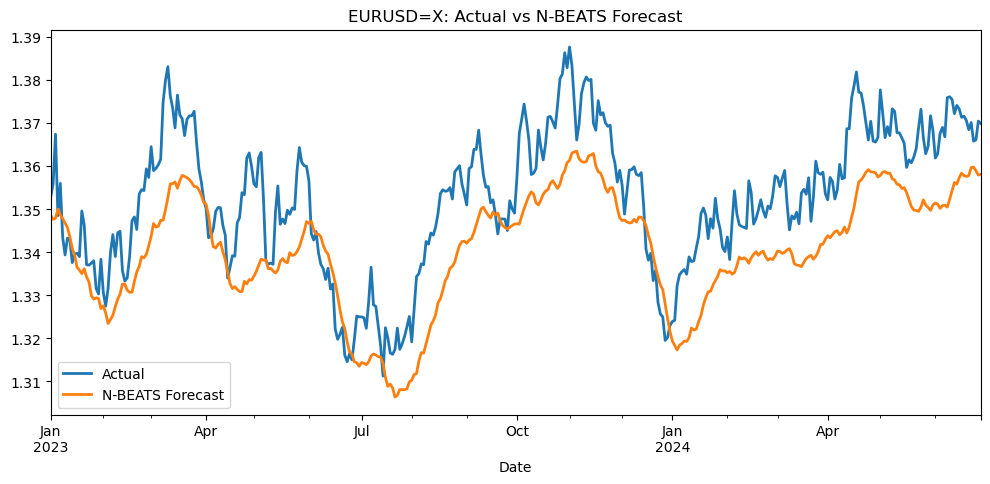

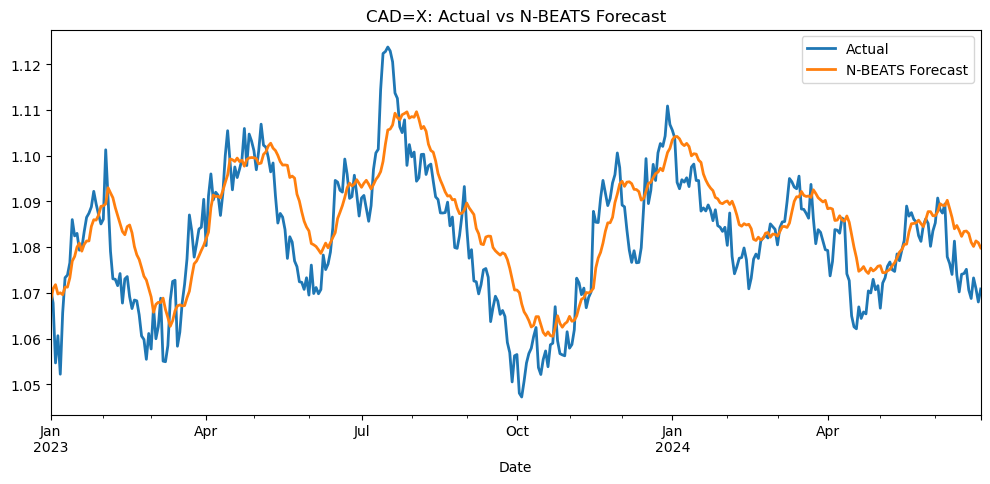

In [71]:
for col in list(data.columns)[1:]:
    plt.figure(figsize=(12, 5))
    
    test_ts[col].plot(label="Actual")
    pred_ts[col].plot(label="N-BEATS Forecast")
    plt.title(f"{col}: Actual vs N-BEATS Forecast")

    plt.legend()
    plt.show()

In [72]:
pred = pred_ts.to_dataframe()

actual = test.copy() 
actual.set_index('Date', inplace=True)

results = pd.merge(actual, pred, left_index=True, right_index=True, how='inner')

new_columns = []
for col in list(data.columns)[1:]:
    new_columns.append(col)
for col in list(data.columns)[1:]:
    new_columns.append(f'{col}_forecast')

results.columns = new_columns

print(results.info())
results

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 390 entries, 2023-01-02 to 2024-06-28
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EURUSD=X           390 non-null    float64
 1   CAD=X              390 non-null    float64
 2   EURUSD=X_forecast  390 non-null    float64
 3   CAD=X_forecast     390 non-null    float64
dtypes: float64(4)
memory usage: 15.2 KB
None


,EURUSD=X,CAD=X,EURUSD=X_forecast,CAD=X_forecast
Date,,,,
2023-01-02,1.35281,1.070973,1.348546,1.068211
2023-01-03,1.35590,1.067771,1.347634,1.070930
2023-01-04,1.36741,1.054685,1.347912,1.071797
2023-01-05,1.34851,1.060637,1.349973,1.069763
2023-01-06,1.35599,1.052222,1.348682,1.070019
...,...,...,...,...
2024-06-24,1.37013,1.068776,1.359670,1.081084
2024-06-25,1.36579,1.073272,1.359787,1.080155
2024-06-26,1.36611,1.070962,1.358921,1.081363


In [73]:
# save results
results.to_csv("../results/forecasts/nbeats_forecasts.csv")

# Tuning


In [ ]:
# Define nbeats model
seed = 42
nbeats_name = "nbeats"

# parameters
params = {
    'lags': [5, 10, 20, 40, 60],
    'steps': [1, 30, 60],
    'stacks': 2,
    'blocks': 2,
    'layers': 2,
    'l_widths': 64,
    'epochs': 10,
    'b_size': 32
}

model_nbeats = NBEATSModel(
    input_chunk_length=params['lags'],       # use last 20 observations
    output_chunk_length=params['steps'],       # forecast 1 step ahead
    generic_architecture=True,
    num_stacks=params['stacks'],
    num_blocks=params['blocks'],
    num_layers=params['layers'],
    layer_widths=params['l_widths'],
    n_epochs=params['epochs'], 
    batch_size=params['b_size'],
    random_state=seed,
    model_name=nbeats_name,
    save_checkpoints=True,
    force_reset=True,
)

# fit model
history = model_nbeats.fit(
    train_scaled, 
    val_series=val_scaled,
    verbose=True)